In [7]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import os
import random
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms

from src.utils.config import load_config
from src.models.model import ReconstructionModel

In [8]:
config = load_config("../configs/config.yaml")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ReconstructionModel(config).to(device)
model.load_state_dict(torch.load("../outputs/model_best.pth", map_location=device))
model.eval()

ReconstructionModel(
  (encoder): Encoder(
    (layer0): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    )
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05

In [9]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

In [10]:
# def show_voxel(voxel, threshold=0.4):
#     voxel = voxel.squeeze()  # [32,32,32]

#     voxel = np.rot90(voxel, k=1, axes=(1, 2))  # (y, z)
#     # voxel = np.rot90(voxel, k=1, axes=(0, 2))  # (x, z)

#     voxel = (voxel > threshold)

#     fig = plt.figure(figsize=(6, 6))
#     ax = fig.add_subplot(111, projection='3d')

#     ax.voxels(voxel, edgecolor='k')

#     plt.show()

def show_voxel(voxel, threshold=0.4, binary=True):
    voxel = voxel.squeeze()
    voxel = np.rot90(voxel, k=1, axes=(1, 2))  # (y, z)

    if binary:
        voxel = (voxel > threshold)

    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')

    ax.voxels(voxel, edgecolor='k')

    plt.show()

def compute_iou(pred, target, threshold=0.4):
    pred = (pred > threshold).astype(np.float32)

    intersection = (pred * target).sum()
    union = ((pred + target) > 0).sum()

    return intersection / (union + 1e-6)

In [11]:
# rendering_path = config["paths"]["rendering_dir"]
# voxel_path = config["paths"]["voxel_dir"]
# class_id = config["data"]["class_id"]

# render_class_path = os.path.join(rendering_path, class_id)
# voxel_class_path = os.path.join(voxel_path, class_id)

# model_ids = os.listdir(render_class_path)

# random_models = random.sample(model_ids, 5)

# for model_id in random_models:
#     render_dir = os.path.join(render_class_path, model_id, "rendering")
#     voxel_file = os.path.join(voxel_class_path, model_id, "model.binvox")

#     if not os.path.exists(render_dir) or not os.path.exists(voxel_file):
#         continue

#     images = [img for img in os.listdir(render_dir) if img.endswith(".png")]
#     if len(images) == 0:
#         continue

#     img_name = random.choice(images)
#     image_path = os.path.join(render_dir, img_name)

#     # 🔥 Load image
#     image = Image.open(image_path).convert("RGB")
#     image_tensor = transform(image).unsqueeze(0).to(device)

#     # 🔥 Model prediction
#     with torch.no_grad():
#         pred_voxel = model(image_tensor).cpu().numpy()

#     # 🔥 Load ground truth voxel
#     import numpy as np
#     from src.utils import binvox_rw

#     with open(voxel_file, 'rb') as f:
#         gt_voxel = binvox_rw.read_as_3d_array(f).data.astype(np.float32)

#     gt_voxel = np.expand_dims(gt_voxel, axis=0)  # match shape [1,32,32,32]

#     # 🔥 Show input image
#     plt.imshow(image)
#     plt.title("Input Image")
#     plt.axis("off")
#     plt.show()

#     # 🔥 Show predicted voxel
#     print("🔵 Predicted Voxel")
#     show_voxel(pred_voxel)

#     # 🔥 Show ground truth voxel
#     print("🟢 Ground Truth Voxel")
#     show_voxel(gt_voxel)


Model ID: 9ab888a92d73e4d4a6ffec31b6fb775
Image: C:/Shivansh/aiml/shapenet/src/data/ShapeNetRendering/ShapeNetRendering\03001627\9ab888a92d73e4d4a6ffec31b6fb775\rendering\02.png
Loaded image and GT voxel
Prediction stats:
Min: 2.2572141e-05 Max: 0.8520402


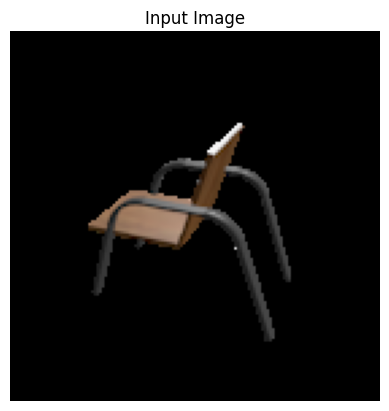

🔵 Predicted Voxel:


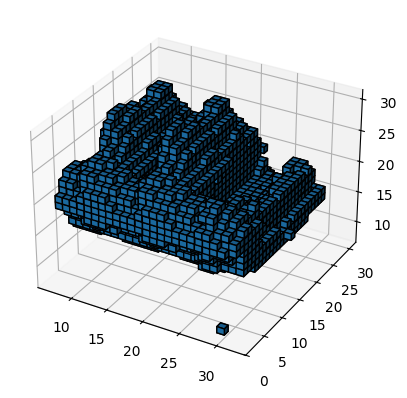

🟢 Ground Truth:


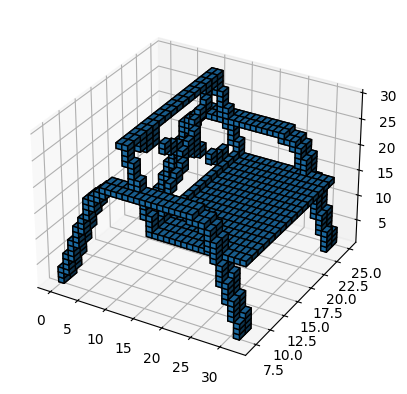

Threshold 0.3: IoU = 0.0684
Threshold 0.4: IoU = 0.0901
Threshold 0.5: IoU = 0.1066

Model ID: 762e86b38d1428fe78e6c2bcdf90770f
Image: C:/Shivansh/aiml/shapenet/src/data/ShapeNetRendering/ShapeNetRendering\03001627\762e86b38d1428fe78e6c2bcdf90770f\rendering\01.png
Loaded image and GT voxel
Prediction stats:
Min: 7.9046025e-05 Max: 0.873776


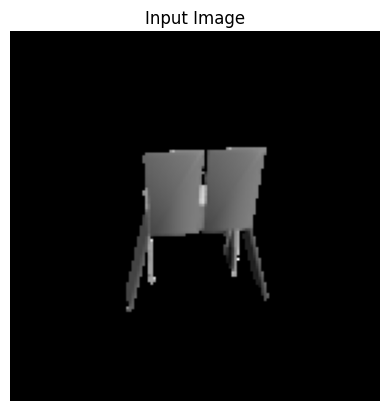

🔵 Predicted Voxel:


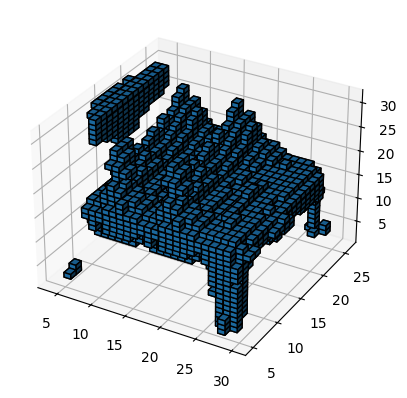

🟢 Ground Truth:


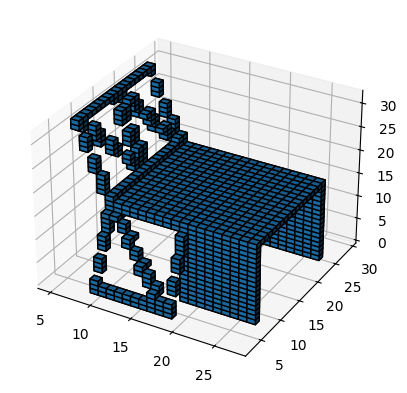

Threshold 0.3: IoU = 0.1081
Threshold 0.4: IoU = 0.1349
Threshold 0.5: IoU = 0.1649

Model ID: f40332e31675a54d492d9da2668ec34c
Image: C:/Shivansh/aiml/shapenet/src/data/ShapeNetRendering/ShapeNetRendering\03001627\f40332e31675a54d492d9da2668ec34c\rendering\23.png
Loaded image and GT voxel
Prediction stats:
Min: 2.6294106e-07 Max: 0.9813867


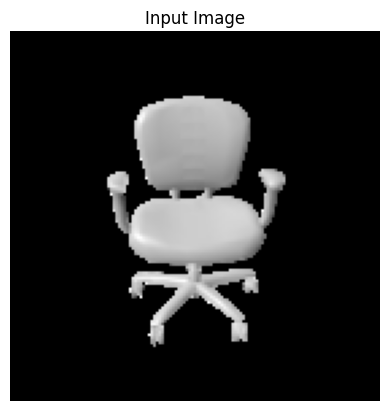

🔵 Predicted Voxel:


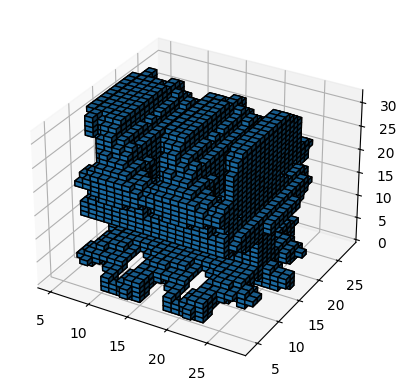

🟢 Ground Truth:


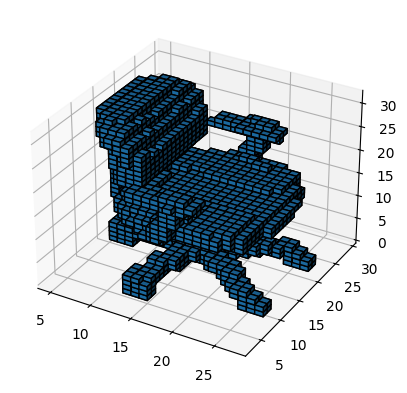

Threshold 0.3: IoU = 0.3650
Threshold 0.4: IoU = 0.3879
Threshold 0.5: IoU = 0.4091

Model ID: 5e598a82d584211d2681d406cc3868fb
Image: C:/Shivansh/aiml/shapenet/src/data/ShapeNetRendering/ShapeNetRendering\03001627\5e598a82d584211d2681d406cc3868fb\rendering\15.png
Loaded image and GT voxel
Prediction stats:
Min: 8.3670415e-07 Max: 0.9939202


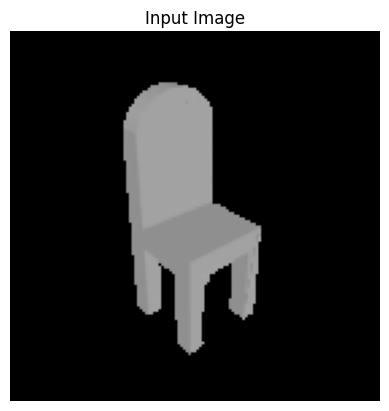

🔵 Predicted Voxel:


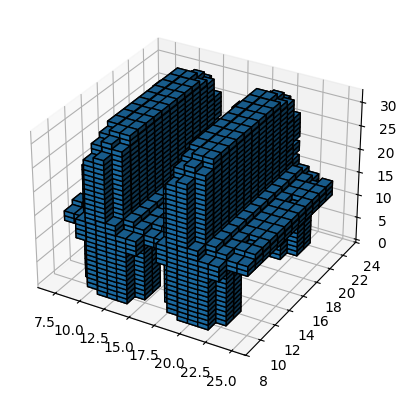

🟢 Ground Truth:


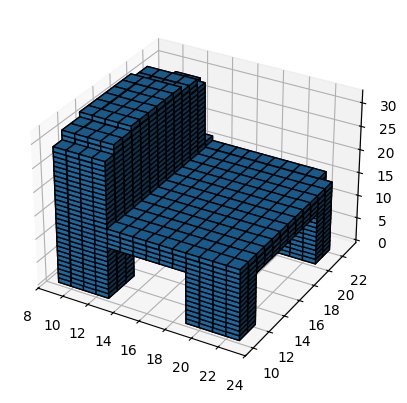

Threshold 0.3: IoU = 0.5461
Threshold 0.4: IoU = 0.5523
Threshold 0.5: IoU = 0.5543

Model ID: 6b91f4fb8cdcd6f46fe24f5659031935
Image: C:/Shivansh/aiml/shapenet/src/data/ShapeNetRendering/ShapeNetRendering\03001627\6b91f4fb8cdcd6f46fe24f5659031935\rendering\12.png
Loaded image and GT voxel
Prediction stats:
Min: 4.8222333e-05 Max: 0.9758698


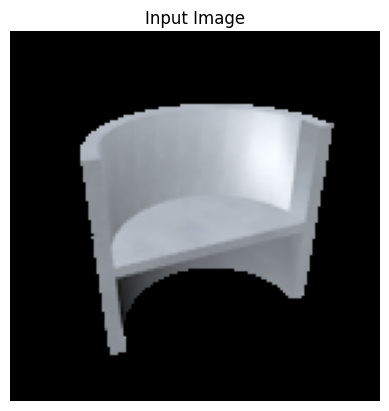

🔵 Predicted Voxel:


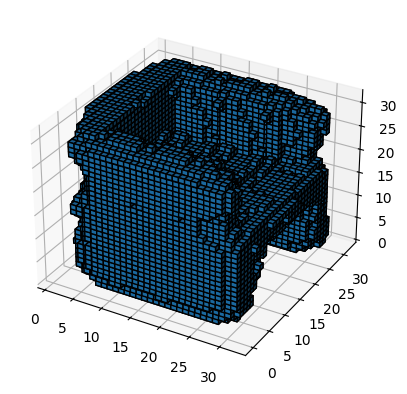

🟢 Ground Truth:


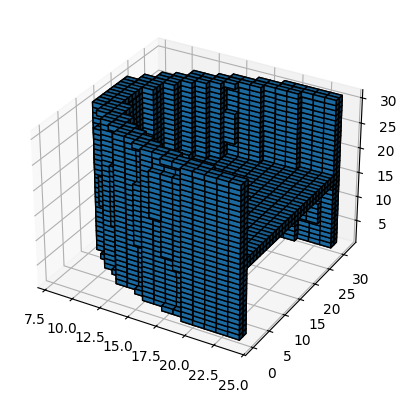

Threshold 0.3: IoU = 0.1449
Threshold 0.4: IoU = 0.1560
Threshold 0.5: IoU = 0.1685


In [14]:
config = load_config("../configs/config.yaml")

render_dir = os.path.join(config["paths"]["rendering_dir"], config["data"]["class_id"])
voxel_dir = os.path.join(config["paths"]["voxel_dir"], config["data"]["class_id"])

model_ids = os.listdir(render_dir)
random_models = random.sample(model_ids, min(5, len(model_ids)))

for model_id in random_models:
    image_folder = os.path.join(render_dir, model_id, "rendering")
    voxel_path = os.path.join(voxel_dir, model_id, "model.binvox")

    if not os.path.exists(image_folder) or not os.path.exists(voxel_path):
        continue

    images = [
        os.path.join(image_folder, f)
        for f in os.listdir(image_folder)
        if f.endswith(".png")
    ]

    if len(images) == 0:
        continue

    image_path = random.choice(images)

    print("\n==============================")
    print("Model ID:", model_id)
    print("Image:", image_path)

    # 🔥 Load image
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)

    import numpy as np
    from src.utils import binvox_rw

    # 🔥 Load GT voxel
    with open(voxel_path, 'rb') as f:
        gt_voxel = binvox_rw.read_as_3d_array(f).data.astype(np.float32)

    gt_voxel = np.expand_dims(gt_voxel, axis=(0,1))  # fix shape

    print("Loaded image and GT voxel")

    # 🔥 Prediction
    with torch.no_grad():
        logits = model(image_tensor)
        pred_voxel = torch.sigmoid(logits).cpu().numpy()

    print("Prediction stats:")
    print("Min:", pred_voxel.min(), "Max:", pred_voxel.max())

    # 🔥 Visualization
    plt.imshow(image)
    plt.title("Input Image")
    plt.axis("off")
    plt.show()

    print("🔵 Predicted Voxel:")
    show_voxel(pred_voxel[0], threshold=0.4)

    print("🟢 Ground Truth:")
    show_voxel(gt_voxel[0], threshold=0.5)

    # 🔥 IoU at multiple thresholds
    for t in [0.3, 0.4, 0.5]:
        iou = compute_iou(pred_voxel[0], gt_voxel[0], threshold=t)
        print(f"Threshold {t}: IoU = {iou:.4f}")